In [7]:
!pip install tensorflow numpy pandas matplotlib pillow tqdm nltk

In [8]:
!rm -f /content/Flickr8k.zip

In [9]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_ca22176cdf99be3e728e1736128a7199"

In [10]:
!pip install -q kaggle

!kaggle datasets download -d adityajn105/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:09<00:00, 121MB/s]



In [11]:
!kaggle datasets download -d adityajn105/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
flickr8k.zip: Skipping, found more recently modified local copy (use --force to force download)


In [12]:
!unzip -q flickr8k.zip -d /content/Flickr8k

print("Extraction Complete!")

Extraction Complete!


In [13]:
import os

print(os.listdir("/content/Flickr8k"))

['captions.txt', 'Images']


In [14]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
import pandas as pd

captions_df = pd.read_csv("/content/Flickr8k/captions.txt")

print("Shape:", captions_df.shape)
captions_df.head()

Shape: (40455, 2)


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [16]:
import string

def clean_caption(text):
    text = text.lower()

    text = ''.join(
        char for char in text
        if char not in string.punctuation
    )

    words = text.split()

    words = [word for word in words if len(word) > 1]

    return ' '.join(words)

captions_df['caption'] = captions_df['caption'].apply(clean_caption)

captions_df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,child in pink dress is climbing up set of stai...
1,1000268201_693b08cb0e.jpg,girl going into wooden building
2,1000268201_693b08cb0e.jpg,little girl climbing into wooden playhouse
3,1000268201_693b08cb0e.jpg,little girl climbing the stairs to her playhouse
4,1000268201_693b08cb0e.jpg,little girl in pink dress going into wooden cabin


In [17]:
captions_df['caption'] = captions_df['caption'].apply(
    lambda x: 'startseq ' + x + ' endseq'
)

captions_df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,startseq child in pink dress is climbing up se...
1,1000268201_693b08cb0e.jpg,startseq girl going into wooden building endseq
2,1000268201_693b08cb0e.jpg,startseq little girl climbing into wooden play...
3,1000268201_693b08cb0e.jpg,startseq little girl climbing the stairs to he...
4,1000268201_693b08cb0e.jpg,startseq little girl in pink dress going into ...


In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(captions_df['caption'])

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 8811


In [19]:
max_length = max(
    len(caption.split())
    for caption in captions_df['caption']
)

print("Maximum Caption Length:", max_length)

Maximum Caption Length: 34


In [20]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.models import Model

model = InceptionV3(weights='imagenet')

model = Model(
    model.input,
    model.layers[-2].output
)

print(model.output_shape)

(None, 2048)


In [21]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.inception_v3 import preprocess_input
import numpy as np

def extract_features(img_path):

    img = image.load_img(
        img_path,
        target_size=(299, 299)
    )

    img = image.img_to_array(img)

    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img)

    feature = model.predict(
        img,
        verbose=0
    )

    return feature

In [22]:
import os

image_dir = "/content/Flickr8k/Images"

sample_img = os.path.join(
    image_dir,
    os.listdir(image_dir)[0]
)

feature = extract_features(sample_img)

print(feature.shape)

(1, 2048)


In [23]:
import os
from tqdm import tqdm

features = {}

image_dir = "/content/Flickr8k/Images"

for img_name in tqdm(os.listdir(image_dir)):

    img_path = os.path.join(
        image_dir,
        img_name
    )

    feature = extract_features(img_path)

    image_id = img_name.split('.')[0]

    features[image_id] = feature

100%|██████████| 8091/8091 [13:59<00:00,  9.63it/s]


In [24]:
import pickle

with open(
    "/content/features.pkl",
    "wb"
) as f:

    pickle.dump(features, f)

print("Features Saved!")

Features Saved!


In [25]:
print("Total Images:", len(features))

first_key = list(features.keys())[0]

print("Sample ID:", first_key)

print(features[first_key].shape)

Total Images: 8091
Sample ID: 2535746605_8124bf4e4f
(1, 2048)


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
!cp /content/features.pkl /content/drive/MyDrive/

In [28]:
import pickle

with open('/content/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [29]:
mapping = {}

for image, caption in zip(
    captions_df['image'],
    captions_df['caption']
):

    image_id = image.split('.')[0]

    if image_id not in mapping:
        mapping[image_id] = []

    mapping[image_id].append(caption)

print("Total Images:", len(mapping))

Total Images: 8091


In [30]:
image_ids = list(mapping.keys())

split = int(len(image_ids) * 0.9)

train = image_ids[:split]
test = image_ids[split:]

print("Train:", len(train))
print("Test:", len(test))

Train: 7281
Test: 810


In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

def data_generator(
    data_keys,
    mapping,
    features,
    tokenizer,
    max_length,
    vocab_size,
    batch_size
):
    X1, X2, y = [], [], []

    n = 0

    while True:

        for key in data_keys:

            n += 1

            captions = mapping[key]

            for caption in captions:

                seq = tokenizer.texts_to_sequences(
                    [caption]
                )[0]

                for i in range(1, len(seq)):

                    in_seq = seq[:i]

                    out_seq = seq[i]

                    in_seq = pad_sequences(
                        [in_seq],
                        maxlen=max_length
                    )[0]

                    out_seq = to_categorical(
                        [out_seq],
                        num_classes=vocab_size
                    )[0]

                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)

            if n == batch_size:

                yield (
                    (
                        np.array(X1),
                        np.array(X2)
                    ),
                    np.array(y)
                )

                X1, X2, y = [], [], []
                n = 0

In [32]:
print(len(mapping))
print(len(train))
print(len(test))

8091
7281
810


In [39]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Embedding,
    Dropout,
    add
)

inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

inputs2 = Input(shape=(max_length,))

se1 = Embedding(
    vocab_size,
    256,
    mask_zero=False
)(inputs2)

se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

decoder1 = add([fe2, se3])

decoder2 = Dense(
    256,
    activation='relu'
)(decoder1)

outputs = Dense(
    vocab_size,
    activation='softmax'
)(decoder2)

model = Model(
    inputs=[inputs1, inputs2],
    outputs=outputs
)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam'
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 34, 256)   │  2,255,616 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 34, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    524,544 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    525,312 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8811)      │  2,264,427 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,635,691 (21.50 MB)

 Trainable params: 5,635,691 (21.50 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
batch_size = 32

steps = len(train) // batch_size

print("Steps Per Epoch:", steps)

Steps Per Epoch: 227


In [40]:
train_generator = data_generator(
    train,
    mapping,
    features,
    tokenizer,
    max_length,
    vocab_size,
    batch_size
)

In [37]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "/content/best_model.keras",
    monitor="loss",
    save_best_only=True,
    verbose=1
)

In [41]:
history = model.fit(
    train_generator,
    epochs=10,
    steps_per_epoch=steps,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - loss: 5.9497
Epoch 1: loss improved from None to 5.23118, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 62s 259ms/step - loss: 5.2312
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 4.1404
Epoch 2: loss improved from 5.23118 to 4.00356, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 245ms/step - loss: 4.0036
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 3.6769
Epoch 3: loss improved from 4.00356 to 3.61188, saving model to /content/best_model.keras

Epoch 3: finished saving model to /content/best_model.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 242ms/step - loss: 3.6119
Epoch 4/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - loss: 3.4177
Epoch 4: loss improved from 3.61188 to 3.37483, saving model to /content/best_model.keras

Epoch 

In [42]:
model.save("/content/image_caption_model.keras")

print("Model Saved!")

Model Saved!


In [43]:
!cp /content/image_caption_model.keras /content/drive/MyDrive/
!cp /content/best_model.keras /content/drive/MyDrive/
!cp /content/tokenizer.pkl /content/drive/MyDrive/
!cp /content/features.pkl /content/drive/MyDrive/

In [44]:
history = model.fit(
    train_generator,
    epochs=10,
    steps_per_epoch=steps,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 2.6549
Epoch 1: loss improved from 2.70092 to 2.63644, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 243ms/step - loss: 2.6364
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 2.6012
Epoch 2: loss improved from 2.63644 to 2.58080, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 54s 240ms/step - loss: 2.5808
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - loss: 2.5490
Epoch 3: loss improved from 2.58080 to 2.53084, saving model to /content/best_model.keras

Epoch 3: finished saving model to /content/best_model.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 55s 241ms/step - loss: 2.5308
Epoch 4/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - loss: 2.5025
Epoch 4: loss improved from 2.53084 to 2.48745, saving model to /content/best_model.keras

Epo

In [46]:
model.save("/content/image_caption_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [47]:
!cp /content/image_caption_model.keras /content/drive/MyDrive/
!cp /content/best_model.keras /content/drive/MyDrive/
!cp /content/tokenizer.pkl /content/drive/MyDrive/
!cp /content/features.pkl /content/drive/MyDrive/

In [48]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def idx_to_word(integer, tokenizer):

    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word

    return None


def predict_caption(model, image_feature, tokenizer, max_length):

    caption = "startseq"

    for _ in range(max_length):

        sequence = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        sequence = pad_sequences(
            [sequence],
            maxlen=max_length
        )

        yhat = model.predict(
            [image_feature, sequence],
            verbose=0
        )

        yhat = np.argmax(yhat)

        word = idx_to_word(
            yhat,
            tokenizer
        )

        if word is None:
            break

        caption += " " + word

        if word == "endseq":
            break

    return caption

In [49]:
sample_id = list(features.keys())[0]

caption = predict_caption(
    model,
    features[sample_id],
    tokenizer,
    max_length
)

print(caption)

startseq little girl in pink shirt is playing with red and white soccer ball endseq


In [50]:
caption = caption.replace(
    "startseq",
    ""
).replace(
    "endseq",
    ""
)

print(caption.strip())

little girl in pink shirt is playing with red and white soccer ball


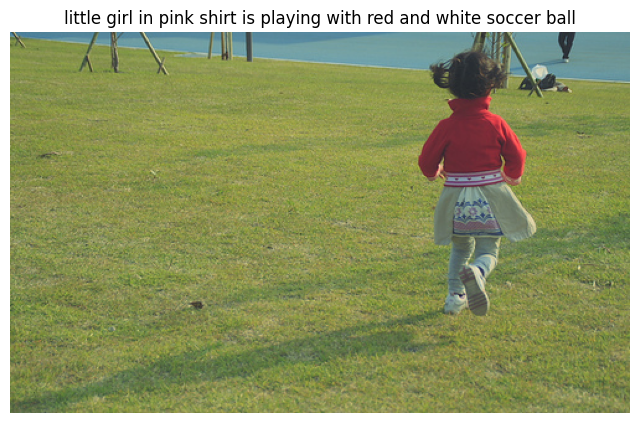

In [51]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_id = sample_id + ".jpg"

img_path = os.path.join(
    "/content/Flickr8k/Images",
    image_id
)

img = Image.open(img_path)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")

plt.title(
    caption.strip(),
    fontsize=12
)

plt.show()

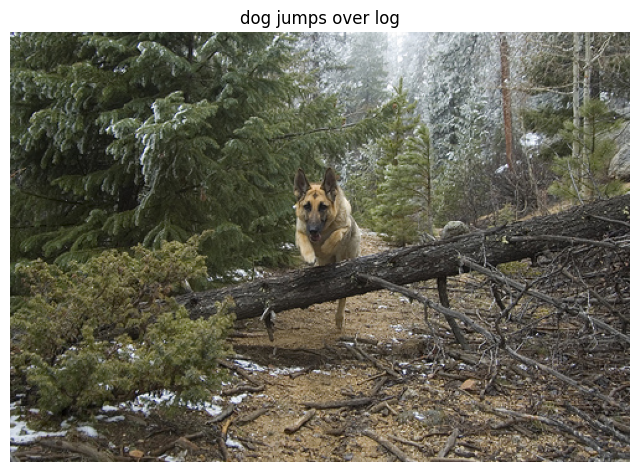

In [52]:
import random
import os
from PIL import Image
import matplotlib.pyplot as plt

test_id = random.choice(test)

caption = predict_caption(
    model,
    features[test_id],
    tokenizer,
    max_length
)

caption = caption.replace(
    "startseq",
    ""
).replace(
    "endseq",
    ""
).strip()

img_path = f"/content/Flickr8k/Images/{test_id}.jpg"

img = Image.open(img_path)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title(caption)
plt.show()